# Linear first-order PDEs: characteristics

We solve the transport IVP $u_t+2u_x=0$, $u(x,0)=x^2$. It is simple enough to derive by hand but rich enough to show the distinction between a planner label and the concrete executor that returns the result.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. DerivationFor$$u_t+2u_x=0,$$choose characteristic curves $x(t)$ so that$$\frac{dx}{dt}=2.$$Hence $x-2t=\xi$ is constant. Along each characteristic,$$\frac{d}{dt}u(x(t),t)=u_t+2u_x=0,$$so $u=f(\xi)$. The initial condition gives $f(\xi)=\xi^2$, therefore$$\boxed{u(x,t)=(x-2t)^2}.$$

In [3]:
x, t = sp.symbols("x t", real=True)
u = sp.Function("u")
eq = sp.Eq(sp.diff(u(x,t),t) + 2*sp.diff(u(x,t),x), 0)
ic = sp.Eq(u(x,0), x**2)
problem = pds.build_pde_problem(eq, u(x,t), (x,t), ics=ic)
recognition, plan = show_plan(problem)

Recognition: (PDERecognitionRecord(family='scalar_conservation_law', recognized=True, solver_hint='conservation_law', tags=('weak_solution', 'riemann_ready'), metadata={'canonical_family': 'transport_reaction'}), PDERecognitionRecord(family='first_order_linear', recognized=True, solver_hint='first_order', tags=('characteristics',), metadata={'constant_coefficient': True}))Top plan steps:  transport_ivp                              score=96  constant_coefficient_inverse_operator      score=92  structured_transform                       score=77  first_order                                score=76  conservation_law                           score=74  symmetry_reduction                         score=52

In [4]:
result = pds.pdesolve([eq, ic], u(x,t), (x,t), method="auto")
print(type(result).__name__, result.method)
display(result.solution)
print("PDESolve verification:", result.verification)

PDESolutionRecord constant_coefficient_characteristics_ivp

PDESolve verification: {'verified': True, 'status': 'verified', 'pde_verified': True, 'initial_verified': True, 'boundary_verified': None, 'pde_residual': 0, 'initial_residuals': (0,), 'boundary_residuals': (), 'mode': 'symbolic', 'message': ''}

## 2. Independent verificationFor an explicit classical solution, verification means exactly what one would do by hand: substitute into the PDE and into the initial trace.

In [5]:
sol = rhs_of(result.solution)
print("PDE residual:", residual(eq, u(x,t), sol))
print("IC residual:", sp.simplify(sol.subs(t,0) - x**2))
assert residual(eq, u(x,t), sol) == 0
assert sp.simplify(sol.subs(t,0)-x**2) == 0

PDE residual: 0IC residual: 0

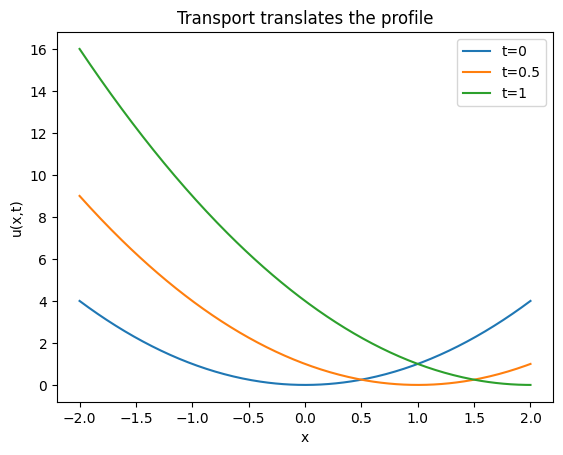

In [6]:
xx = np.linspace(-2, 2, 300)
fig, ax = plt.subplots()
for tv in [0.0, 0.5, 1.0]:
    ax.plot(xx, (xx-2*tv)**2, label=f"t={tv:g}")
ax.set_xlabel("x"); ax.set_ylabel("u(x,t)"); ax.set_title("Transport translates the profile")
ax.legend(); plt.show()

## 3. Variation and exercisesThe runnable variation below changes the speed and profile. Then try: (1) derive the general solution of $u_t+c u_x=0$; (2) predict how the planner changes if the initial condition is removed; (3) replace the polynomial profile by $e^{-x^2}$.

constant_coefficient_characteristics_ivp

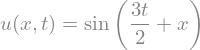

In [7]:
c = -sp.Rational(3,2)
profile = sp.sin(x)
eq2 = sp.Eq(sp.diff(u(x,t),t) + c*sp.diff(u(x,t),x), 0)
ic2 = sp.Eq(u(x,0), profile)
r2 = pds.pdesolve([eq2, ic2], u(x,t), (x,t), method="auto")
print(r2.method); display(r2.solution)